# Plots for Tomograhy paper draft

## Install and Import Required Packages

In [1]:

%%capture out
%pip install matplotlib
%pip install scipy
%pip install matplotlib
%pip install tdqm
%pip install scienceplots


In [2]:
import os
import sys

os.environ["PATH"] += os.pathsep + '/Library/TeX/texbin'

if __name__ == '__main__':
    root_dir = 'Transmon-Project'
    root_path = os.path.abspath('').split(root_dir)[0] + root_dir
    sys.path.append(root_path)

import numpy as np
import scipy as sp
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import scienceplots

from matplotlib.font_manager import FontProperties

from circuit_models.resonator_coupling_circuit_projected import RCCircuitCoup

from tqdm import tqdm

plt.style.use('science')

h = 6.62607015e-34
hbar = 1.054571817e-34
e_charge = 1.60217663e-1



The "RCCircuitCoup" module has been imported. This module allows to calculate the parallel and perpendicular coupling in a circuit of a flux qubit (probe) coupled to a resonator coupled to a transmon qubit. The method uses an Hamiltonian term projected into the probe qubit subspace.


## Example of instance created

In [3]:
systemProj = RCCircuitCoup(ncut=5)

g_parr = systemProj.calc_g_parr()
print(f"g parallel: {g_parr}")

g_perp = systemProj.calc_g_perp()
print(f"g perpendicular: {g_perp}")

delta = systemProj.calc_probe_freq()
print(f"delta: {delta}")


g parallel: (-1.1165854167175472e-25-9.585329915212375e-40j)
g perpendicular: (3.5288506863583123e-39-9.768283442714626e-40j)
delta: (1.1476996077542005e-24+8.816207603843326e-39j)



## Visualise Hamiltonians

/var/folders/v9/3g_zjkfs0cbb96f2ccc429l00000gq/T/ipykernel_68286/978050463.py:5: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  if type(H_p) == sp.sparse.csr.csr_matrix:


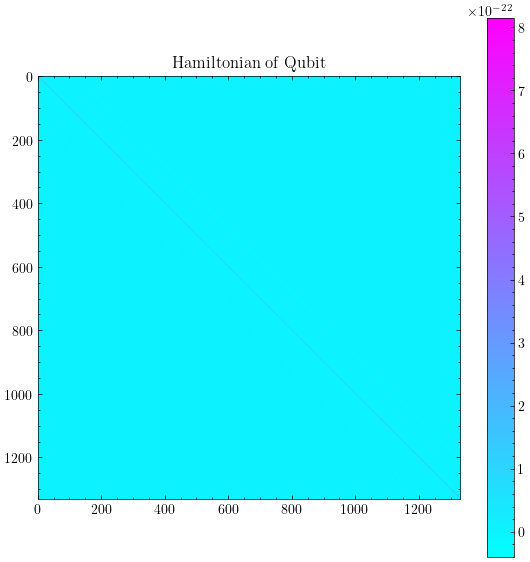

In [4]:
system = RCCircuitCoup(ncut=5)

H_p = system.get_H_p()

if type(H_p) == sp.sparse.csr.csr_matrix:
    H_p = H_p.toarray()

f = plt.figure(figsize=(15,7))

ax2 = f.add_subplot(122)
ax2.title.set_text('Hamiltonian of Qubit')
im2 = ax2.imshow(np.real(H_p), cmap=plt.get_cmap('cool'))
f.colorbar(im2)
plt.show()

/var/folders/v9/3g_zjkfs0cbb96f2ccc429l00000gq/T/ipykernel_68286/3075671245.py:6: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  if type(kin_p) == sp.sparse.csr.csr_matrix:


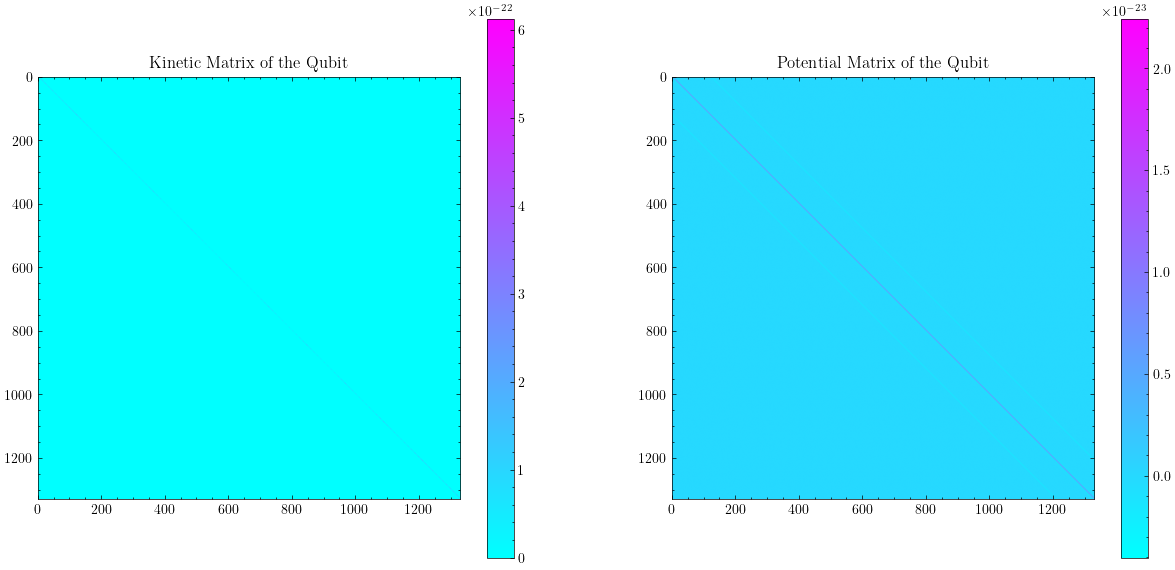

In [5]:
system = RCCircuitCoup(ncut=5, ng=0.5, Ejp=121e8)

kin_p = system.kin_p()
pot_p = system.pot_p()

if type(kin_p) == sp.sparse.csr.csr_matrix:
    kin_p = kin_p.toarray()
    pot_p = pot_p.toarray()

f = plt.figure(figsize=(15,7))

ax1 = f.add_subplot(121)
ax1.title.set_text('Kinetic Matrix of the Qubit')
im1 = ax1.imshow(np.real(kin_p), cmap=plt.get_cmap('cool'))
f.colorbar(im1)

ax2 = f.add_subplot(122)
ax2.title.set_text('Potential Matrix of the Qubit')
im2 = ax2.imshow(np.real(pot_p), cmap=plt.get_cmap('cool'))
f.colorbar(im2)
plt.show()

## Qubit Spectrum

In [6]:
evals_list = []
fluxes = np.linspace(0,1,200)

system = RCCircuitCoup(ncut=5, ng=0)
for flux in tqdm(fluxes):
    system.flux = flux
    evals, evecs = system.diagonalise_p(update=True)
    #evals_list.append(np.diff(evals[:5]))
    #evals_list.append(evals[:5]-evals[0])
    evals_list.append(evals[:5])

evals = np.asarray(evals_list)

100%|██████████| 200/200 [00:07<00:00, 28.09it/s]


/Users/e.lupo/miniconda3/envs/envQv2/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/e.lupo/miniconda3/envs/envQv2/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


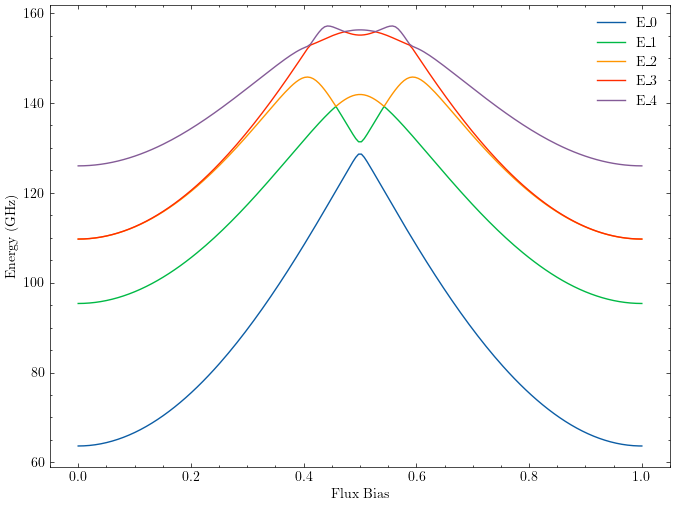

In [7]:
plt.figure(figsize=(8,6))
plt.plot(fluxes, (evals * 1e-9) / h)
plt.xlabel('Flux Bias')
plt.ylabel('Energy (GHz)')
plt.legend([f'E_{n} ' for n in range(len(evals))])
plt.show()

## Qubit Simulation

#### Qubit gap varying $n_g$ and $\alpha$

In [8]:
fig_17a_ngs_p = np.linspace(-1, 1, 200)
# alphas = np.linspace(0.25, 0.6, 8)
alphas = [0.2, 0.4, 0.6]

system = RCCircuitCoup(ncut=5, Ccp=0)

fig_17a_results_p = {}

for alpha in alphas:
    fig_17a_results_p[alpha] = []
    system.alphas = [alpha, alpha, 1, 1]

    system._print_params()

    for ng in tqdm(fig_17a_ngs_p):
        system.ng = ng

        evals, evecs = system.diagonalise_p(update=True)
        evals = np.real(evals) * 1e-9 / h

        delta = evals[1] - evals[0]

        fig_17a_results_p[alpha].append(delta)

Ejp:    8.01746e-23
Cjp:    8e-15
Ccp:    0
alphas: [0.2, 0.2, 1, 1]
ng:    0.25
flux:  0.5
Cr:    1e-13
Lr:    1e-08
Ejt:   3.3129999999999996e-24
Cjt:   4e-15
Cct:   5e-15
Ct:   4e-14


100%|██████████| 200/200 [00:08<00:00, 22.26it/s]


Ejp:    8.01746e-23
Cjp:    8e-15
Ccp:    0
alphas: [0.4, 0.4, 1, 1]
ng:    1.0
flux:  0.5
Cr:    1e-13
Lr:    1e-08
Ejt:   3.3129999999999996e-24
Cjt:   4e-15
Cct:   5e-15
Ct:   4e-14


100%|██████████| 200/200 [00:07<00:00, 28.09it/s]


Ejp:    8.01746e-23
Cjp:    8e-15
Ccp:    0
alphas: [0.6, 0.6, 1, 1]
ng:    1.0
flux:  0.5
Cr:    1e-13
Lr:    1e-08
Ejt:   3.3129999999999996e-24
Cjt:   4e-15
Cct:   5e-15
Ct:   4e-14


100%|██████████| 200/200 [00:06<00:00, 29.91it/s]


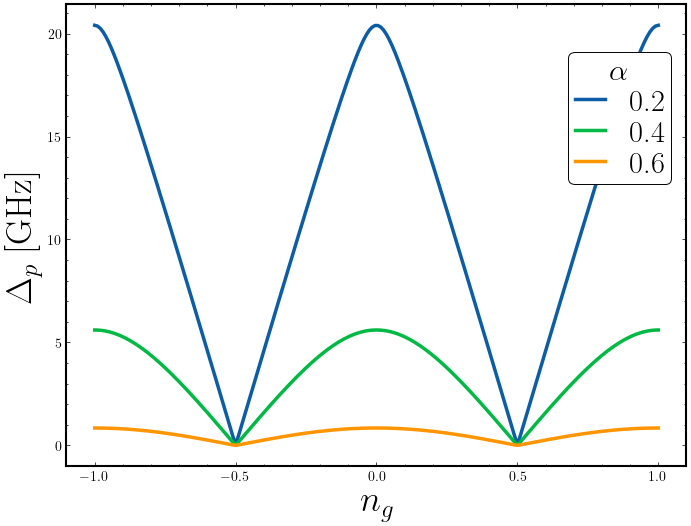

In [9]:
font = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 26}

fontlabel = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 22}

plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes
for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Set the desired thickness

#plt.title('Probe qubit energy gap', **font)
plt.xlabel('$n_g$', **font)
plt.ylabel('$\\Delta_p$ [GHz]', **font)

plt.rc('font', **fontlabel)

for alpha in fig_17a_results_p.keys():
    plt.plot(fig_17a_ngs_p, fig_17a_results_p[alpha], label=round(alpha,2), linewidth=2.5)

legend = plt.legend(title='$\\alpha$', loc= 'upper right', bbox_to_anchor=(1.0, 0.93),labelspacing=0.12, handlelength=1, borderpad=0.2, frameon=True, 
    facecolor='white', 
    edgecolor='black', 
    framealpha=1 )

# Adjust the border thickness
legend.get_frame().set_linewidth(0.7)  # Set the desired thickness

plt.show()

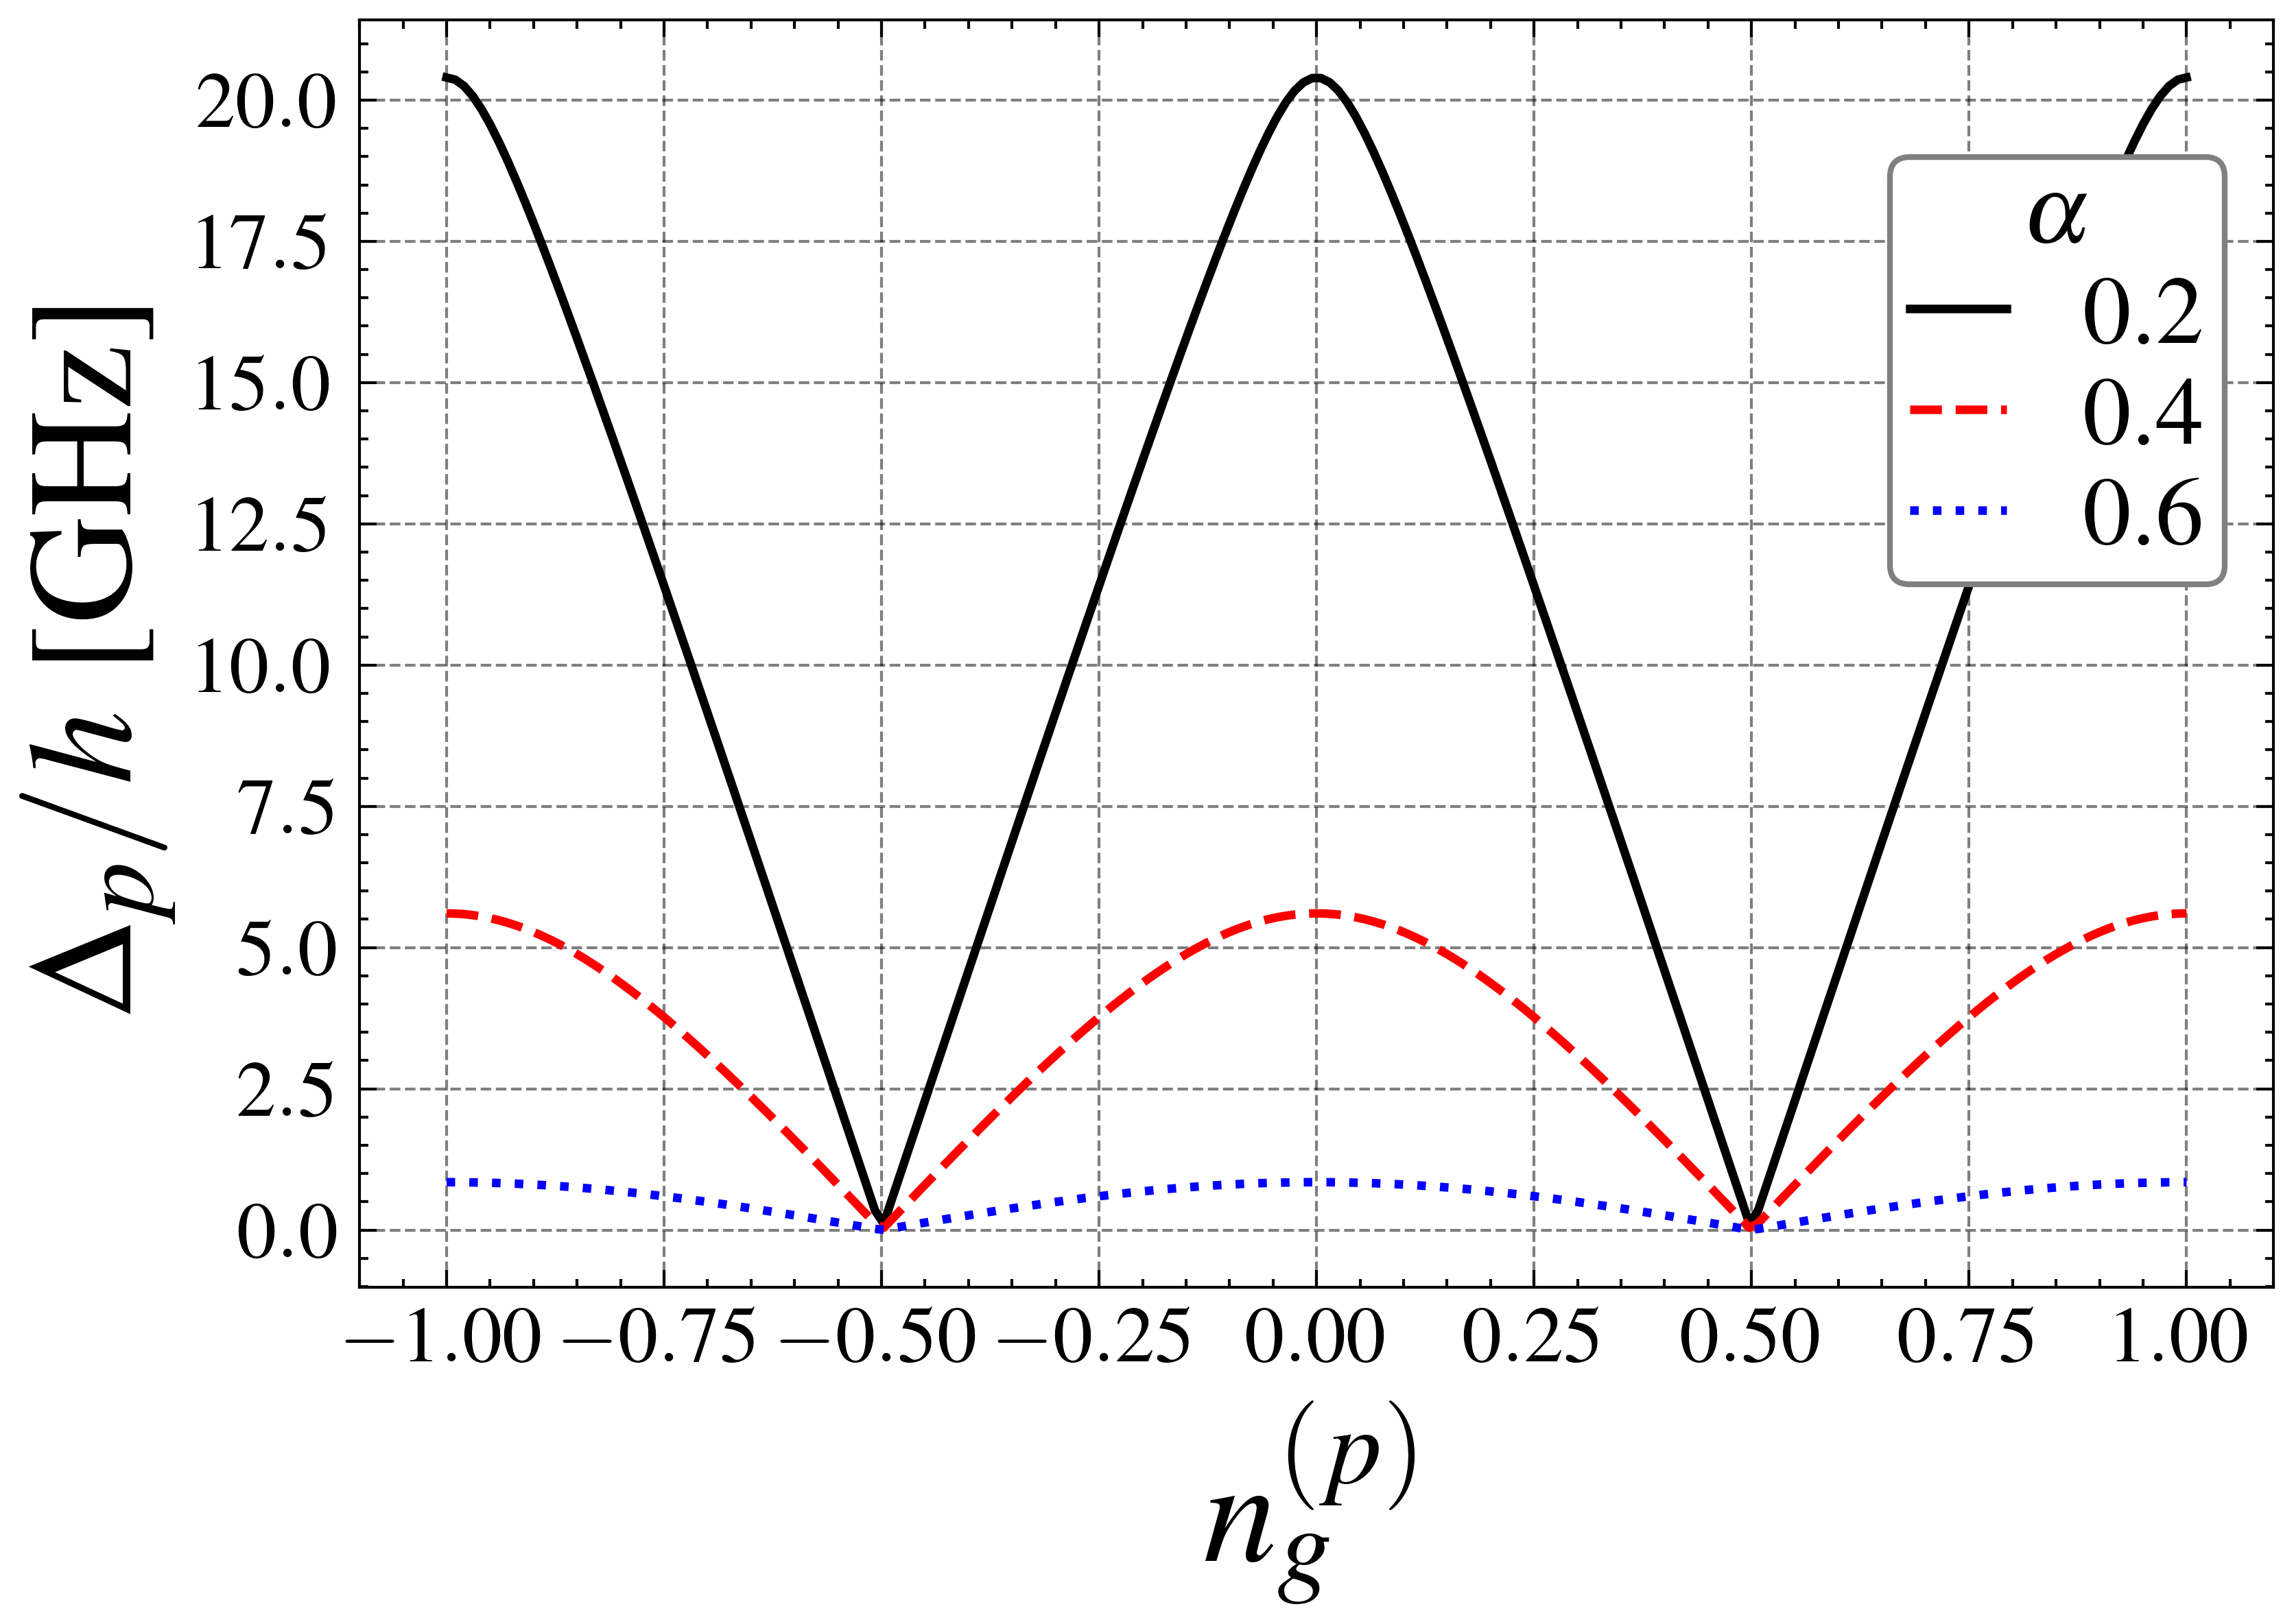

In [21]:
font = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 26}

fontlabel = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 17} 

fontticksaxis = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 14} 

# Create FontProperties objects
font_properties = FontProperties(**font)
fontlabel_properties = FontProperties(**fontlabel)
fontticksaxis_properties = FontProperties(**fontticksaxis) 
        
pparam = dict(xlabel='$n_g^{(p)}$', ylabel='$\\Delta_p / h$ [GHz]')

with plt.style.context(['ieee', 'grid']):
    fig, ax = plt.subplots(figsize=(6,4))
    for alpha in fig_17a_results_p.keys():
        ax.plot(fig_17a_ngs_p, fig_17a_results_p[alpha], label=round(alpha,2), linewidth=1.5)

    ax.legend(title='$\\alpha$', title_fontsize=fontlabel['size'], prop=fontlabel_properties,loc= 'upper right', bbox_to_anchor=(1.0, 0.93),labelspacing=0.12, handlelength=1, borderpad=0.2, frameon=True, 
    facecolor='white', 
    edgecolor='grey', 
    framealpha=1 )
    ax.set(**pparam)
    ax.xaxis.label.set_fontproperties(font_properties)
    ax.yaxis.label.set_fontproperties(font_properties)

    # Update the tick labels font
    for xxx in ax.get_xticklabels() + ax.get_yticklabels():
        xxx.set_fontproperties(fontticksaxis_properties)
        
    #fig.savefig('/Users/e.lupo/Documents/00 Elenas files/charge tomography/Dan python codes last/figures/Resonator Coupling/Delta_wrt_alpha_ng_bis.png', dpi=400)
    plt.show()

#### Qubit gap varying $n_g$ and $C_{cp}$

In [11]:
fig_17b_ngs_p = np.linspace(-1, 1, 200)
# fig_17b_Ccs_p = np.linspace(0, 10e-15, 12)
fig_17b_Ccps_p = [0e-15, 5e-15, 10e-15]

system = RCCircuitCoup(ncut=5)

fig_17b_results_p = {}

for CcpV in fig_17b_Ccps_p:
    fig_17b_results_p[CcpV] = []
    system.Ccp = CcpV

    system._print_params()

    for ng in tqdm(fig_17b_ngs_p):
        system.ng = ng

        delta = system.calc_probe_freq(update=True) * 1e-9 / h

        fig_17b_results_p[CcpV].append(delta)

Ejp:    8.01746e-23
Cjp:    8e-15
Ccp:    0.0
alphas: [0.4, 0.4, 1, 1]
ng:    0.25
flux:  0.5
Cr:    1e-13
Lr:    1e-08
Ejt:   3.3129999999999996e-24
Cjt:   4e-15
Cct:   5e-15
Ct:   4e-14


100%|██████████| 200/200 [00:08<00:00, 22.56it/s]


Ejp:    8.01746e-23
Cjp:    8e-15
Ccp:    5e-15
alphas: [0.4, 0.4, 1, 1]
ng:    1.0
flux:  0.5
Cr:    1e-13
Lr:    1e-08
Ejt:   3.3129999999999996e-24
Cjt:   4e-15
Cct:   5e-15
Ct:   4e-14


100%|██████████| 200/200 [00:09<00:00, 20.90it/s]


Ejp:    8.01746e-23
Cjp:    8e-15
Ccp:    1e-14
alphas: [0.4, 0.4, 1, 1]
ng:    1.0
flux:  0.5
Cr:    1e-13
Lr:    1e-08
Ejt:   3.3129999999999996e-24
Cjt:   4e-15
Cct:   5e-15
Ct:   4e-14


100%|██████████| 200/200 [00:09<00:00, 22.08it/s]


/Users/e.lupo/miniconda3/envs/envQv2/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/e.lupo/miniconda3/envs/envQv2/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


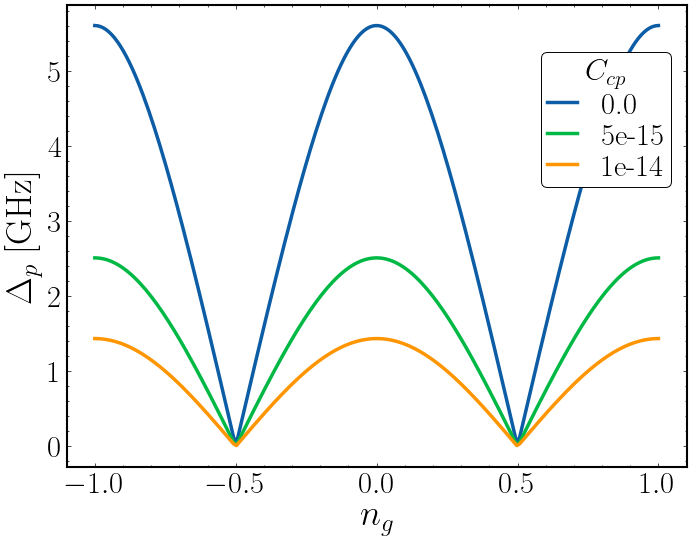

In [12]:
font = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 26}

fontlabel = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 22}

plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes
for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Set the desired thickness

#plt.title('Qubit energy gap (calculated from eigenenergies)')
plt.xlabel('$n_g$', **font)
plt.ylabel('$\\Delta_p$ [GHz]', **font)

plt.rc('font', **fontlabel)

for Ccp in fig_17b_results_p.keys():
    plt.plot(fig_17b_ngs_p, fig_17b_results_p[Ccp], label=Ccp, linewidth=2.5)

legend =plt.legend(title='$C_{cp}$', loc= 'upper right', bbox_to_anchor=(1.0, 0.93),labelspacing=0.12, handlelength=1, borderpad=0.2, frameon=True, 
    facecolor='white', 
    edgecolor='black', 
    framealpha=1 )

# Adjust the border thickness
legend.get_frame().set_linewidth(0.7)  # Set the desired thickness

plt.show()




/Users/e.lupo/miniconda3/envs/envQv2/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/e.lupo/miniconda3/envs/envQv2/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


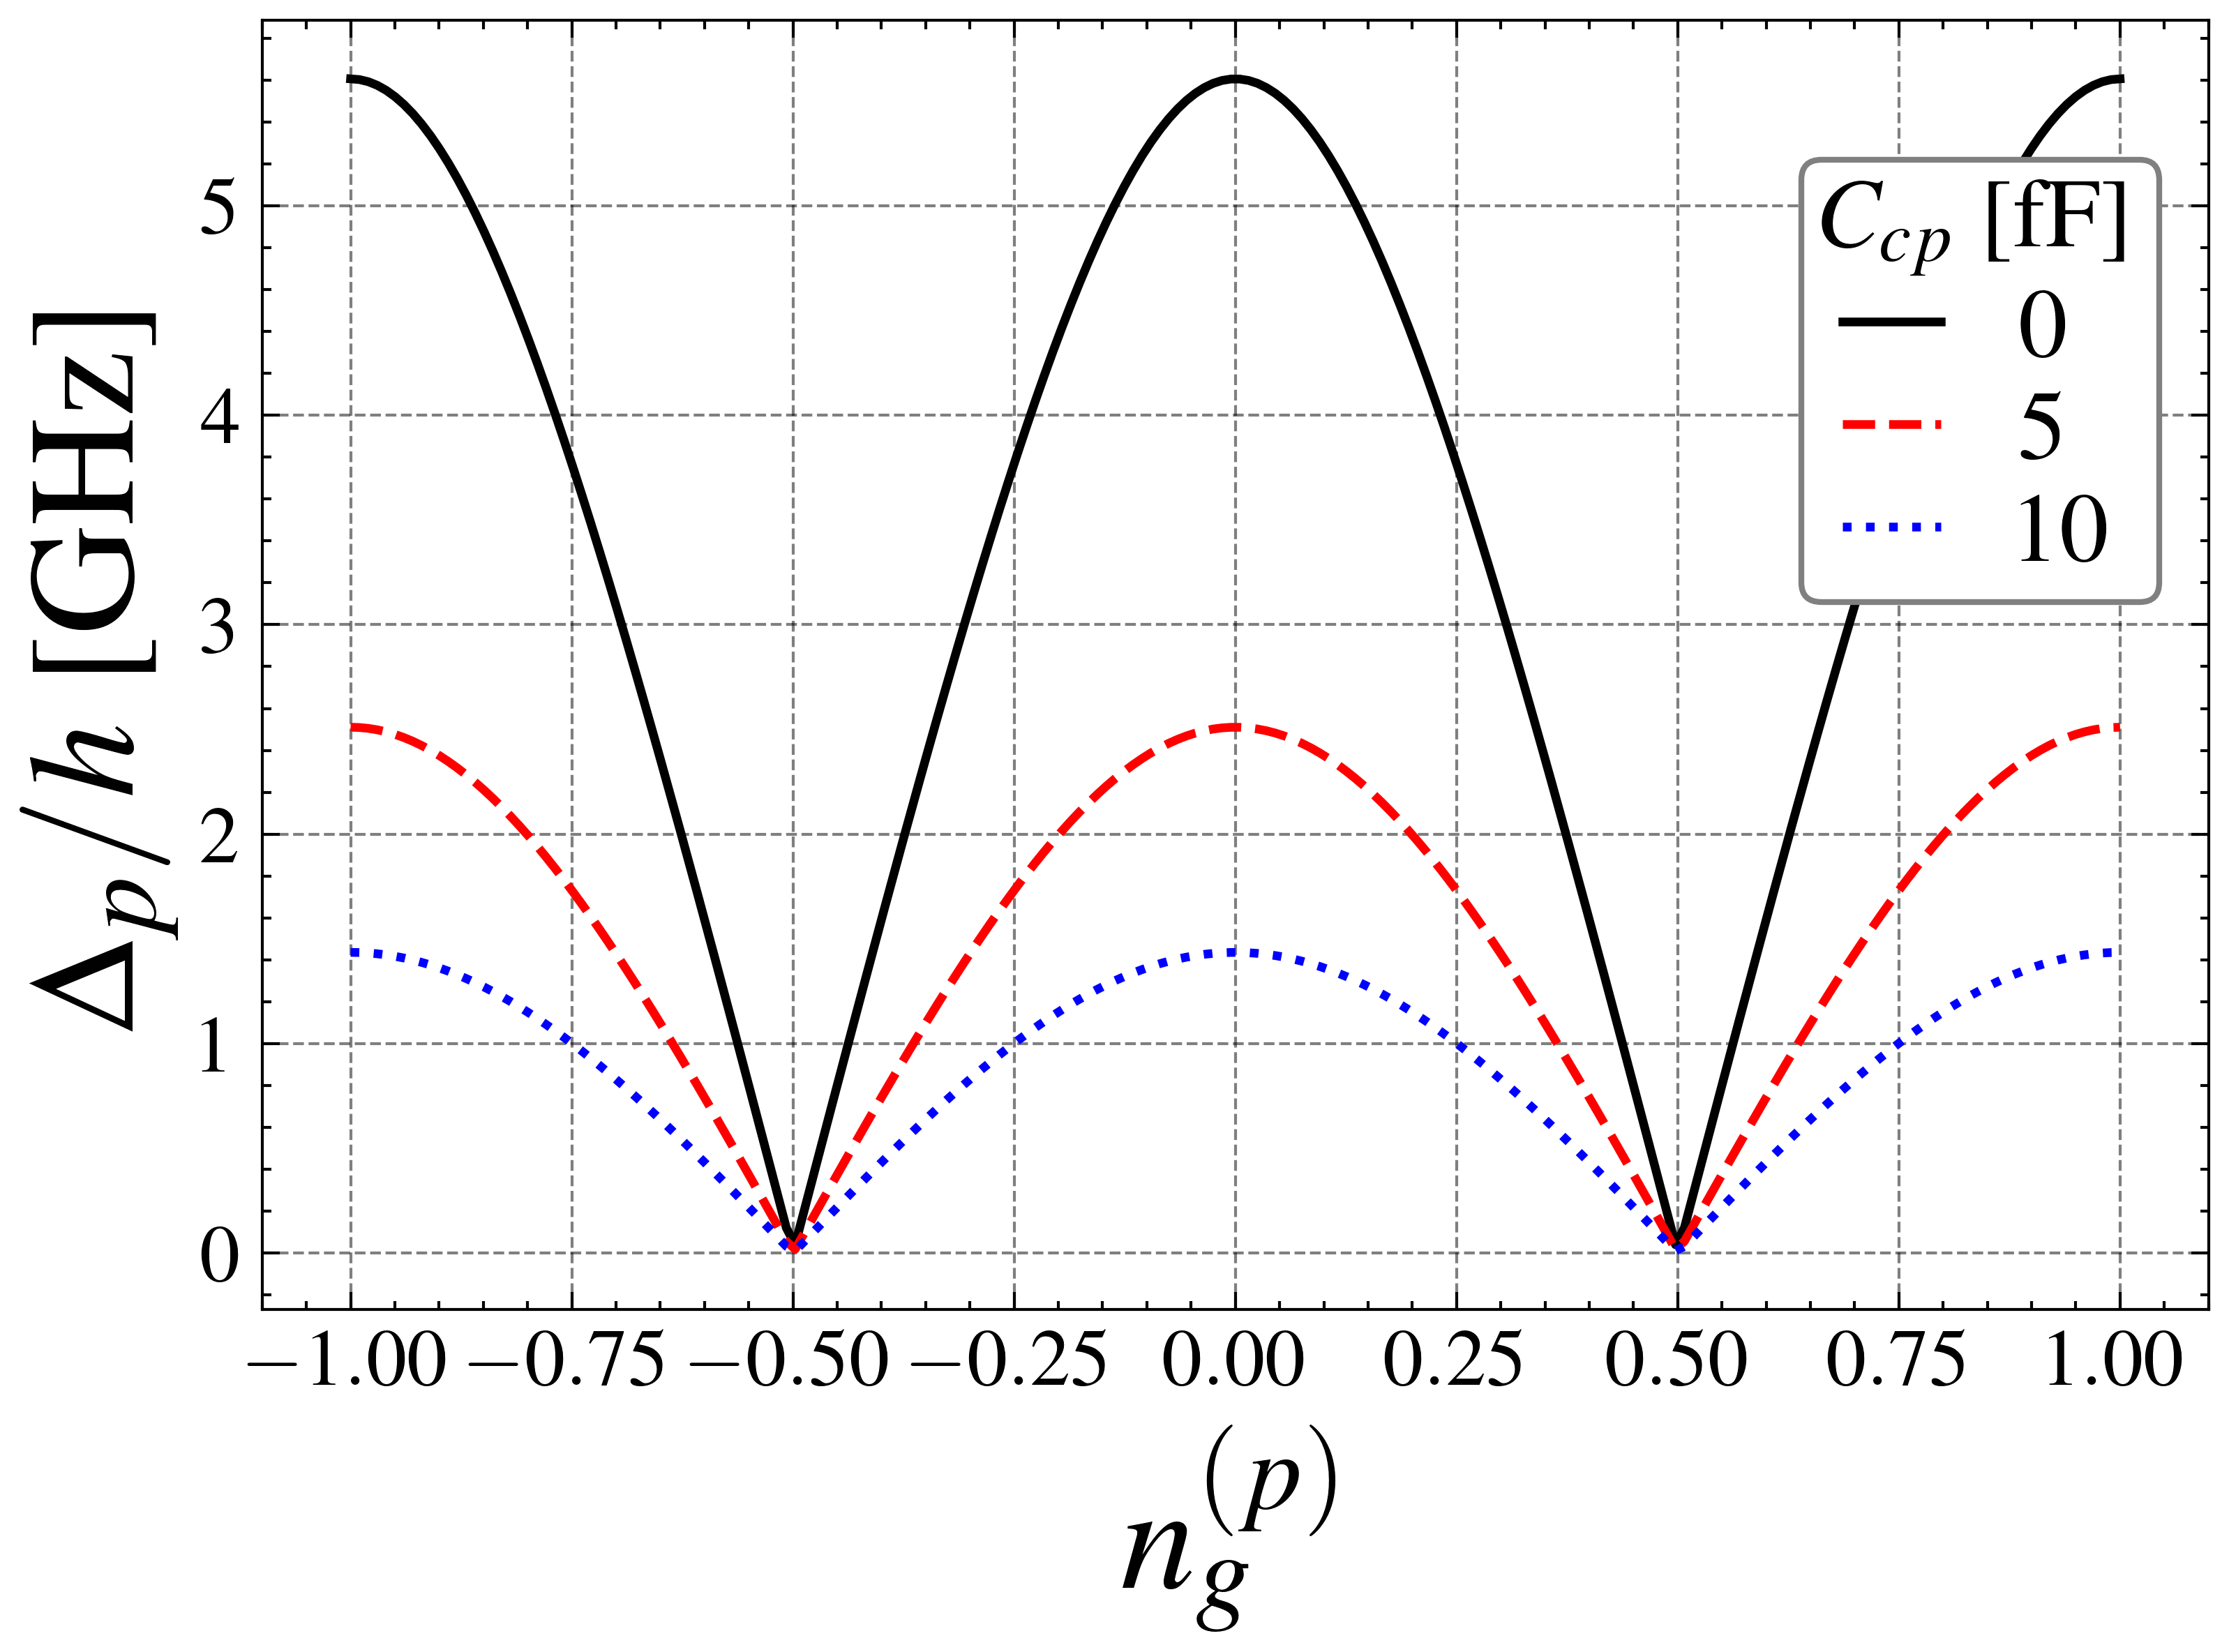

In [14]:
font = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 26}

fontlabel = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 17} 

fontticksaxis = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 14} 

# Create FontProperties objects
font_properties = FontProperties(**font)
fontlabel_properties = FontProperties(**fontlabel)
fontticksaxis_properties = FontProperties(**fontticksaxis) 
        
pparam = dict(xlabel='$n_g^{(p)}$', ylabel='$\\Delta_p / h$ [GHz]')

with plt.style.context(['ieee', 'grid']):
    fig2, ax = plt.subplots(figsize=(6,4))
    for Ccp in fig_17b_results_p.keys():
        ax.plot(fig_17b_ngs_p, fig_17b_results_p[Ccp], label=int(Ccp * 1e15), linewidth=1.5)

    ax.legend(title='$C_{cp}$ [fF]', title_fontsize=fontlabel['size'], prop=fontlabel_properties,loc= 'upper right', bbox_to_anchor=(1.0, 0.93),labelspacing=0.12, handlelength=1, borderpad=0.2, frameon=True, 
    facecolor='white', 
    edgecolor='grey', 
    framealpha=1 )
    ax.set(**pparam)
    ax.xaxis.label.set_fontproperties(font_properties)
    ax.yaxis.label.set_fontproperties(font_properties)

    # Update the tick labels font
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(fontticksaxis_properties)
        
    #fig2.savefig('/Users/e.lupo/Documents/00 Elenas files/charge tomography/Dan python codes last/figures/Resonator Coupling/Delta_wrt_Ccp_ng_bis.png', dpi=400)
    plt.show()

#### $g_\parallel^{(pc)}$ and $g_\perp^{(pc)}$ varying $n_g$ and $C_{cp}$

In [15]:
fig_17c_ngs_p = np.linspace(-1, 1, 200)
# fig_17c_Ccps_p = [val * 1e-15 for val in range(1,9)]
fig_17c_Ccps_p = [1e-15, 4e-15, 8e-15]

system = RCCircuitCoup(ncut=5)

fig_17c_g_parr_results = {}
fig_17c_g_perp_results = {}

for CcpV in fig_17c_Ccps_p:
    fig_17c_g_parr_results[CcpV] = []
    fig_17c_g_perp_results[CcpV] = []
    system.Ccp = CcpV

    system._print_params()

    for ng in tqdm(fig_17c_ngs_p):
        system.ng = ng

        system.init_probe_states(update=True)

        g_parr = system.calc_g_parr() * 1e-6 / h
        g_perp = system.calc_g_perp() * 1e-6 / h

        fig_17c_g_parr_results[CcpV].append(g_parr)
        fig_17c_g_perp_results[CcpV].append(g_perp)

Ejp:    8.01746e-23
Cjp:    8e-15
Ccp:    1e-15
alphas: [0.4, 0.4, 1, 1]
ng:    0.25
flux:  0.5
Cr:    1e-13
Lr:    1e-08
Ejt:   3.3129999999999996e-24
Cjt:   4e-15
Cct:   5e-15
Ct:   4e-14


100%|██████████| 200/200 [00:08<00:00, 24.23it/s]


Ejp:    8.01746e-23
Cjp:    8e-15
Ccp:    4e-15
alphas: [0.4, 0.4, 1, 1]
ng:    1.0
flux:  0.5
Cr:    1e-13
Lr:    1e-08
Ejt:   3.3129999999999996e-24
Cjt:   4e-15
Cct:   5e-15
Ct:   4e-14


100%|██████████| 200/200 [00:07<00:00, 25.55it/s]


Ejp:    8.01746e-23
Cjp:    8e-15
Ccp:    8e-15
alphas: [0.4, 0.4, 1, 1]
ng:    1.0
flux:  0.5
Cr:    1e-13
Lr:    1e-08
Ejt:   3.3129999999999996e-24
Cjt:   4e-15
Cct:   5e-15
Ct:   4e-14


100%|██████████| 200/200 [00:08<00:00, 22.54it/s]


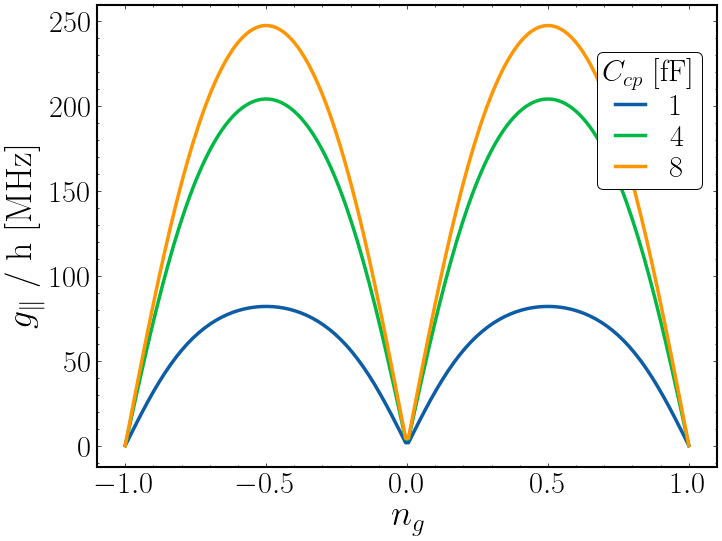

In [16]:
font = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 26}

fontlabel = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 22}

plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes
for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Set the desired thickness

plt.xlabel('$n_g$', **font)
plt.ylabel('$g_\\parallel$ / h [MHz]', **font)

plt.rc('font', **fontlabel)

for Ccp in fig_17c_g_parr_results.keys():
    plt.plot(fig_17c_ngs_p, np.abs(fig_17c_g_parr_results[Ccp]), label=round(Ccp * 1e15), linewidth=2.5)


legend = plt.legend(title='$C_{cp}$ [fF]', loc= 'upper right', bbox_to_anchor=(1.0, 0.93),labelspacing=0.12, handlelength=1, borderpad=0.2, frameon=True, 
    facecolor='white', 
    edgecolor='black', 
    framealpha=1 )

# Adjust the border thickness
legend.get_frame().set_linewidth(0.7)  # Set the desired thickness

plt.show()





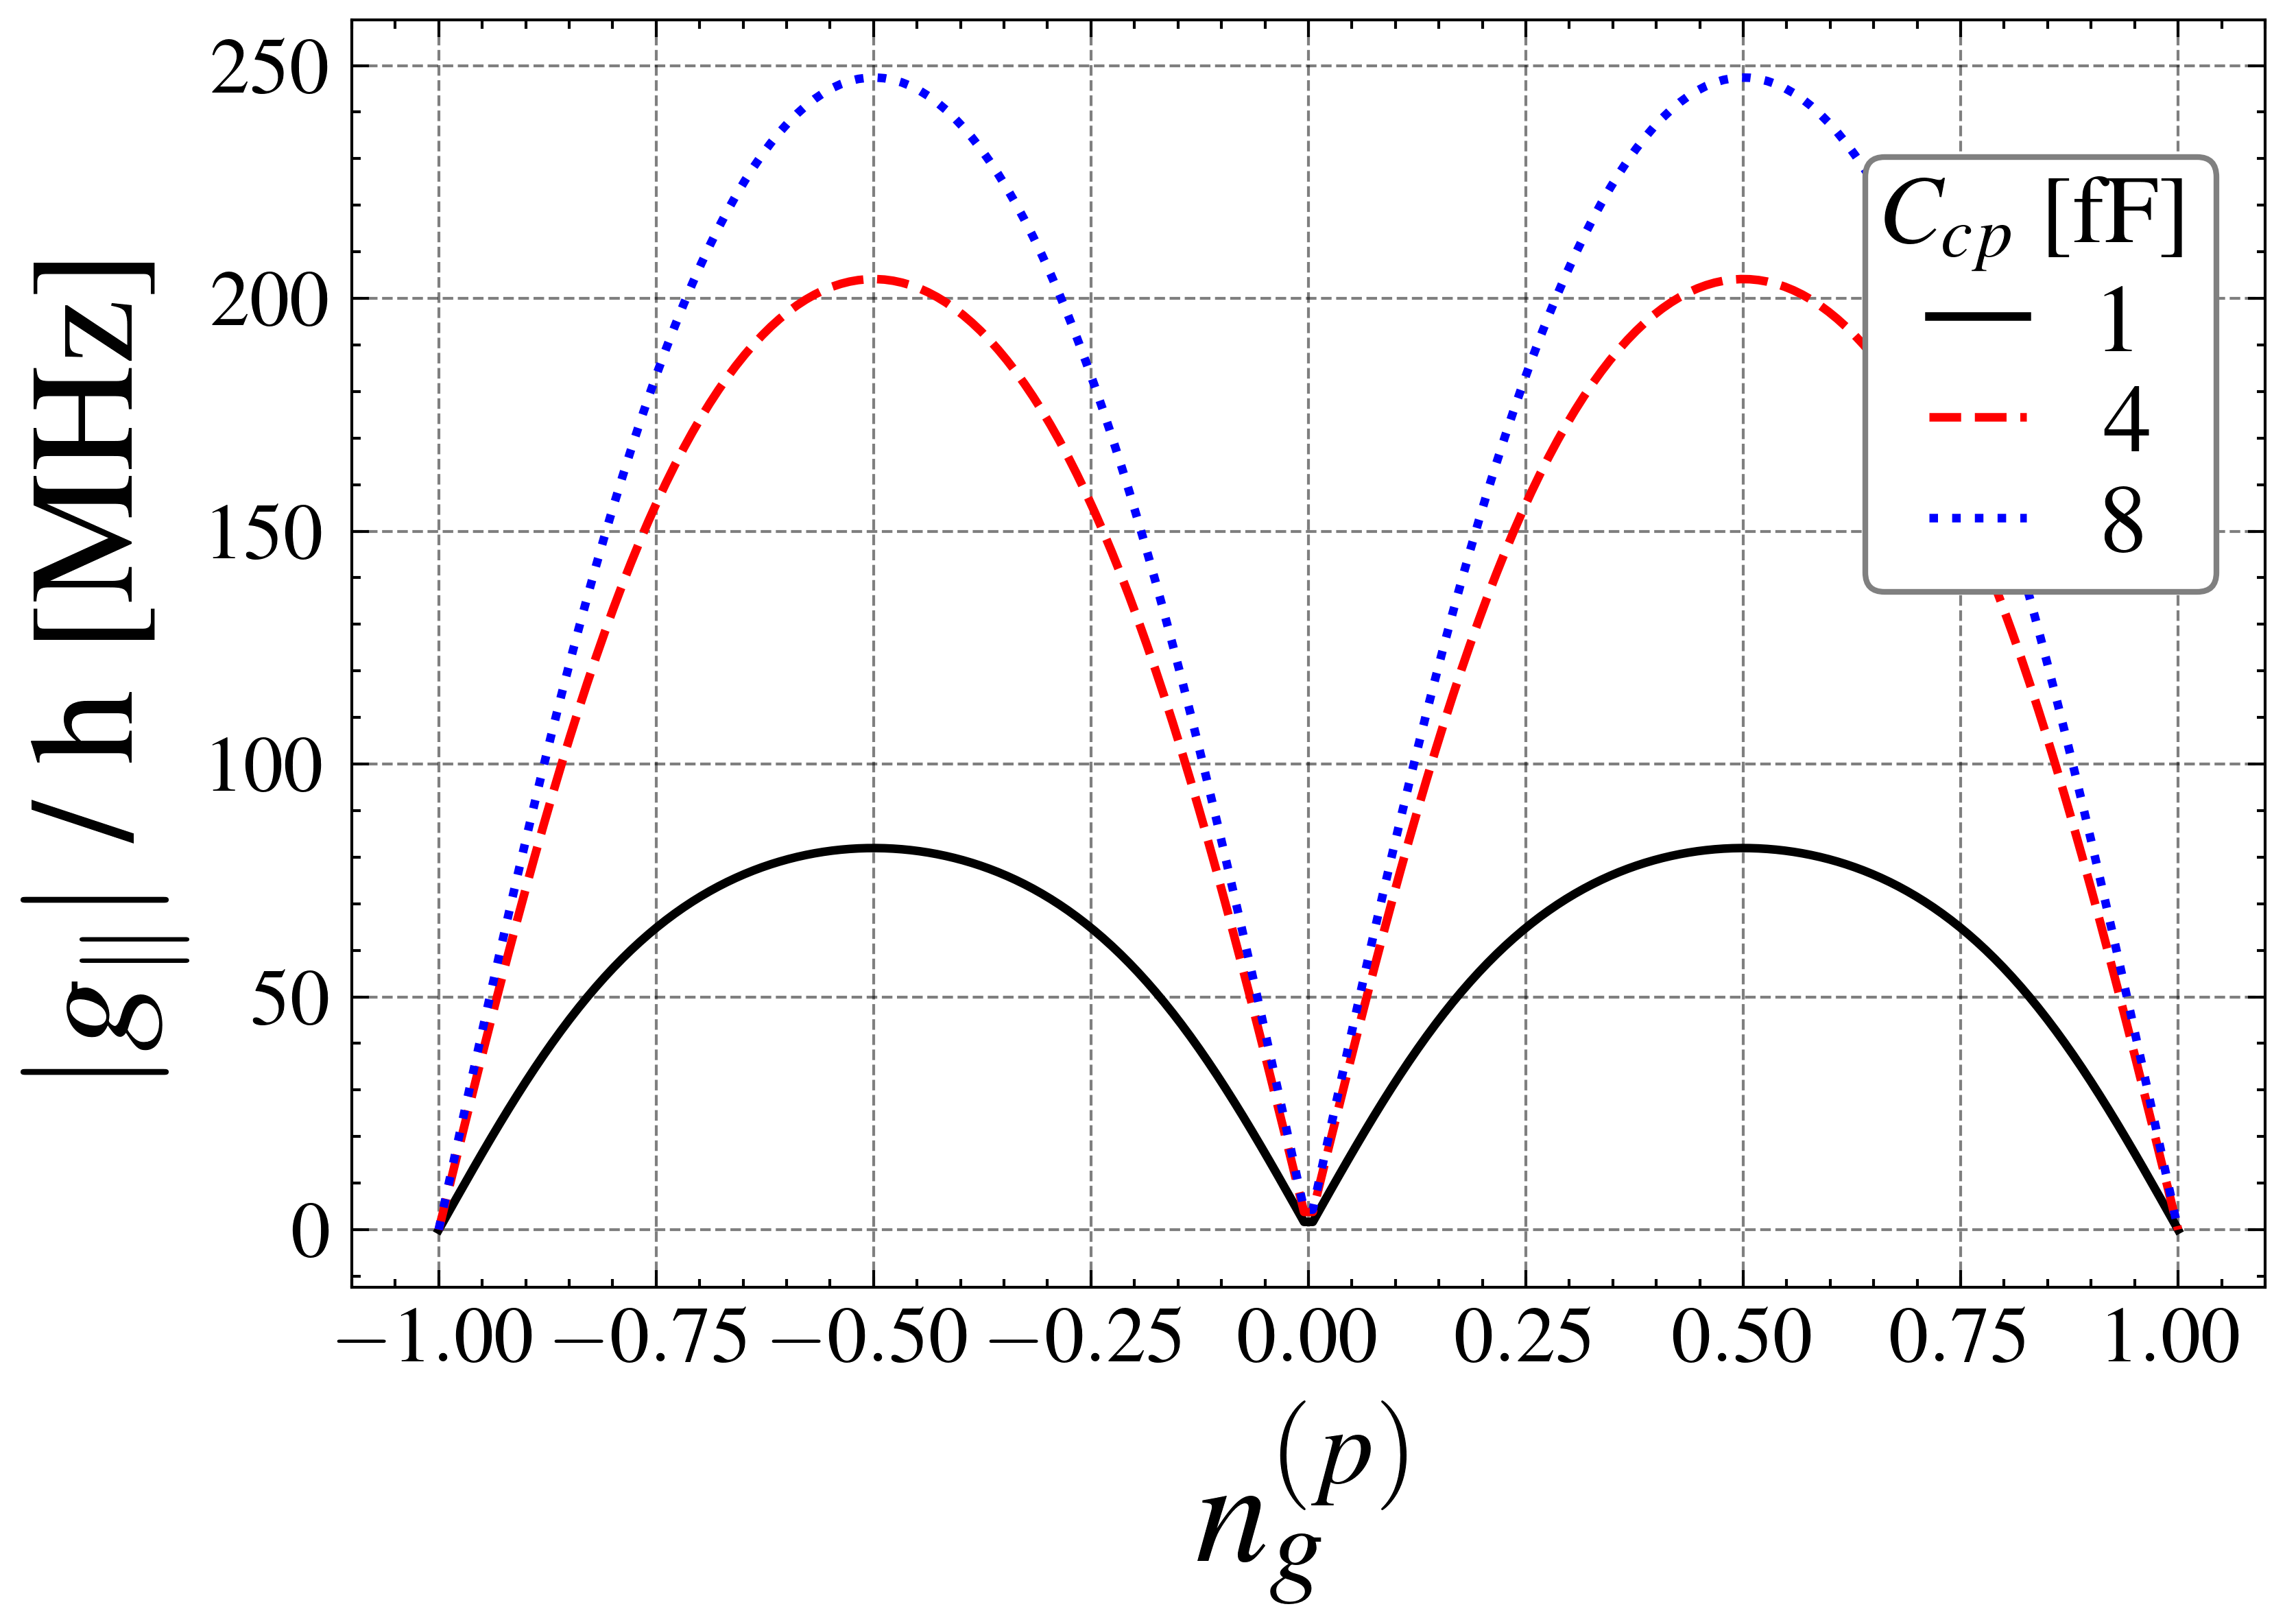

In [17]:
font = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 26}

fontlabel = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 17} 

fontticksaxis = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 14} 

# Create FontProperties objects
font_properties = FontProperties(**font)
fontlabel_properties = FontProperties(**fontlabel)
fontticksaxis_properties = FontProperties(**fontticksaxis) 
        
pparam = dict(xlabel='$n_g^{(p)}$', ylabel='$|g_\\parallel|$ / h [MHz]')

with plt.style.context(['ieee', 'grid']):
    fig2, ax = plt.subplots(figsize=(6,4))
    for Ccp in fig_17c_g_parr_results.keys():
        plt.plot(fig_17c_ngs_p, np.abs(fig_17c_g_parr_results[Ccp]), label=round(Ccp * 1e15), linewidth=1.5)

    ax.legend(title='$C_{cp}$ [fF]', title_fontsize=fontlabel['size'], prop=fontlabel_properties,loc= 'upper right', bbox_to_anchor=(1.0, 0.93),labelspacing=0.12, handlelength=1, borderpad=0.2, frameon=True, 
    facecolor='white', 
    edgecolor='grey', 
    framealpha=1 )
    ax.set(**pparam)
    ax.xaxis.label.set_fontproperties(font_properties)
    ax.yaxis.label.set_fontproperties(font_properties)

    # Update the tick labels font
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(fontticksaxis_properties)
        
    #fig2.savefig('/Users/e.lupo/Documents/00 Elenas files/charge tomography/Dan python codes last/figures/Resonator Coupling/g_parr_wrt_Ccp_ng_bis.png', dpi=400)
    plt.show()

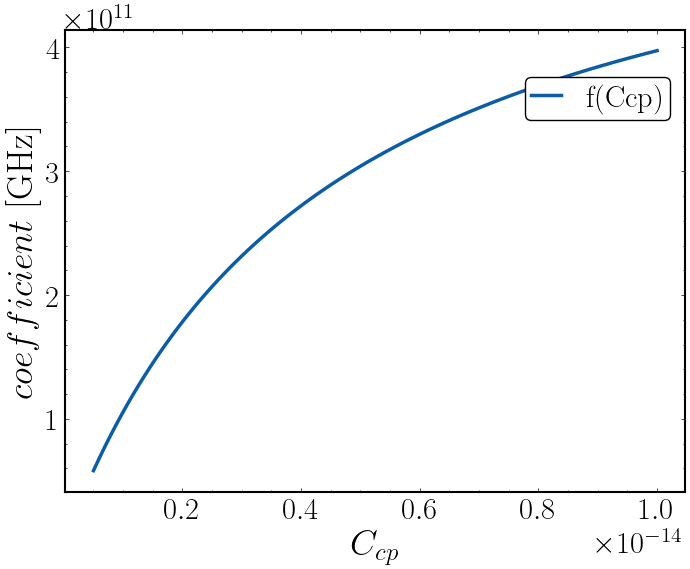

In [18]:
# Check if coefficinet of g_parr increases as I increase Ccp..

Ccp_range = np.linspace(0.5, 10, 100)*1e-15

c_values = []
ccp_values=[]

system = RCCircuitCoup()

for x in Ccp_range:

    system.Ccp = x

    system.get_C_mat_in()
    invCmat = system.C_mat_in

    Cr_tilde = 1/(invCmat[3][3])
    Zr_tilde = np.sqrt(system.Lr / Cr_tilde)
    coeff = (1 / (4 * np.pi * Zr_tilde))**0.5

    coup = coeff*( 2 * invCmat[0][3]/system.alphas[0] +  2 * invCmat[1][3]/system.alphas[1] + 2 * invCmat[2][3]/(1+system.alphas[2]) )

    ccp_values.append(system.Ccp)
    c_values.append(coup)


font = {'family' : 'roman',
    'weight' : 'bold',
    'size'   : 26}

fontlabel = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 22}

plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes
for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Set the desired thickness

#plt.title('Qubit energy gap (calculated from eigenenergies)')
plt.xlabel('$C_{cp}$', **font)
plt.ylabel('$coefficient$ [GHz]', **font)

plt.rc('font', **fontlabel)

plt.plot(Ccp_range, c_values, label='f(Ccp)', linewidth=2.5)

plt.legend(loc= 'upper right', bbox_to_anchor=(1.0, 0.93),labelspacing=0.12, handlelength=1, borderpad=0.2, frameon=True, 
    facecolor='white', 
    edgecolor='black', 
    framealpha=1 )

# Adjust the border thickness
legend.get_frame().set_linewidth(0.7)  # Set the desired thickness

plt.show()




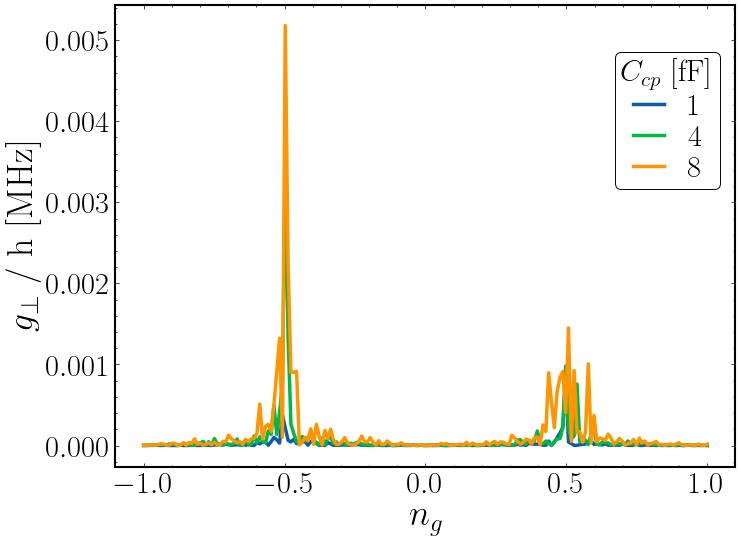

In [22]:
font = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 26}

fontlabel = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 22}

plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes
for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Set the desired thickness

plt.xlabel('$n_g$', **font)
plt.ylabel('$g_\\perp$ / h [MHz]', **font)

plt.rc('font', **fontlabel)

for Cc in fig_17c_g_perp_results.keys():
    ax.plot(fig_17c_ngs_p, [np.abs(val) * 1e6 for val in fig_17c_g_perp_results[Cc]], label=round(Cc * 1e15), linewidth=2.5)


legend = plt.legend(title='$C_{cp}$ [fF]', loc= 'upper right', bbox_to_anchor=(1.0, 0.93),labelspacing=0.12, handlelength=1, borderpad=0.2, frameon=True, 
    facecolor='white', 
    edgecolor='black', 
    framealpha=1 )

# Adjust the border thickness
legend.get_frame().set_linewidth(0.7)  # Set the desired thickness

plt.show()




#### $g_\parallel^{(pc)}$ varying $C_{cp}$

In [23]:
fig_17d_Ccps_p = np.linspace(0, 10e-15, 100)

fig_17d_results_p = []

system = RCCircuitCoup(ncut=5, ng=0.25)
for Ccp in tqdm(fig_17d_Ccps_p):
    system.Ccp = Ccp

    g_parr = system.calc_g_parr(update=True) * 1e-6 / h

    fig_17d_results_p.append(g_parr)

100%|██████████| 100/100 [00:04<00:00, 22.62it/s]


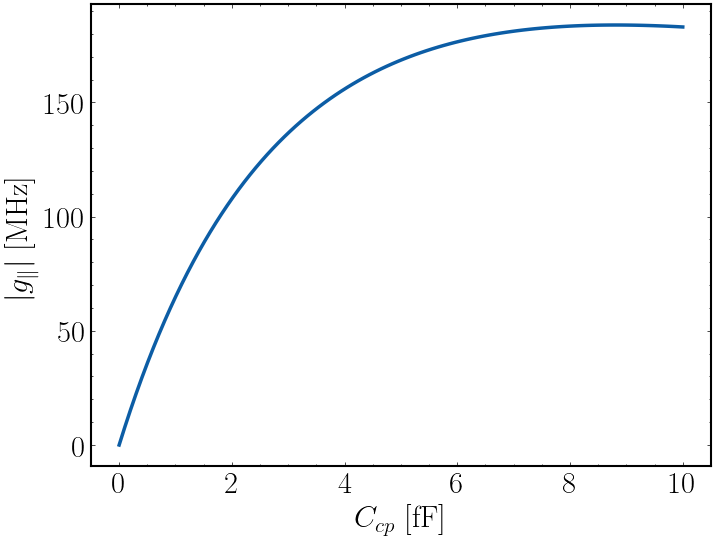

In [24]:
font = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 26}

fontlabel = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 22}

plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes
for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Set the desired thickness

plt.xlabel('$C_{cp}$ [fF]')
plt.ylabel('$|g_\\parallel|$ [MHz]')

plt.rc('font', **fontlabel)

plt.plot([val * 1e15 for val in fig_17d_Ccps_p], np.abs(fig_17d_results_p), linewidth=2.5)

plt.show()


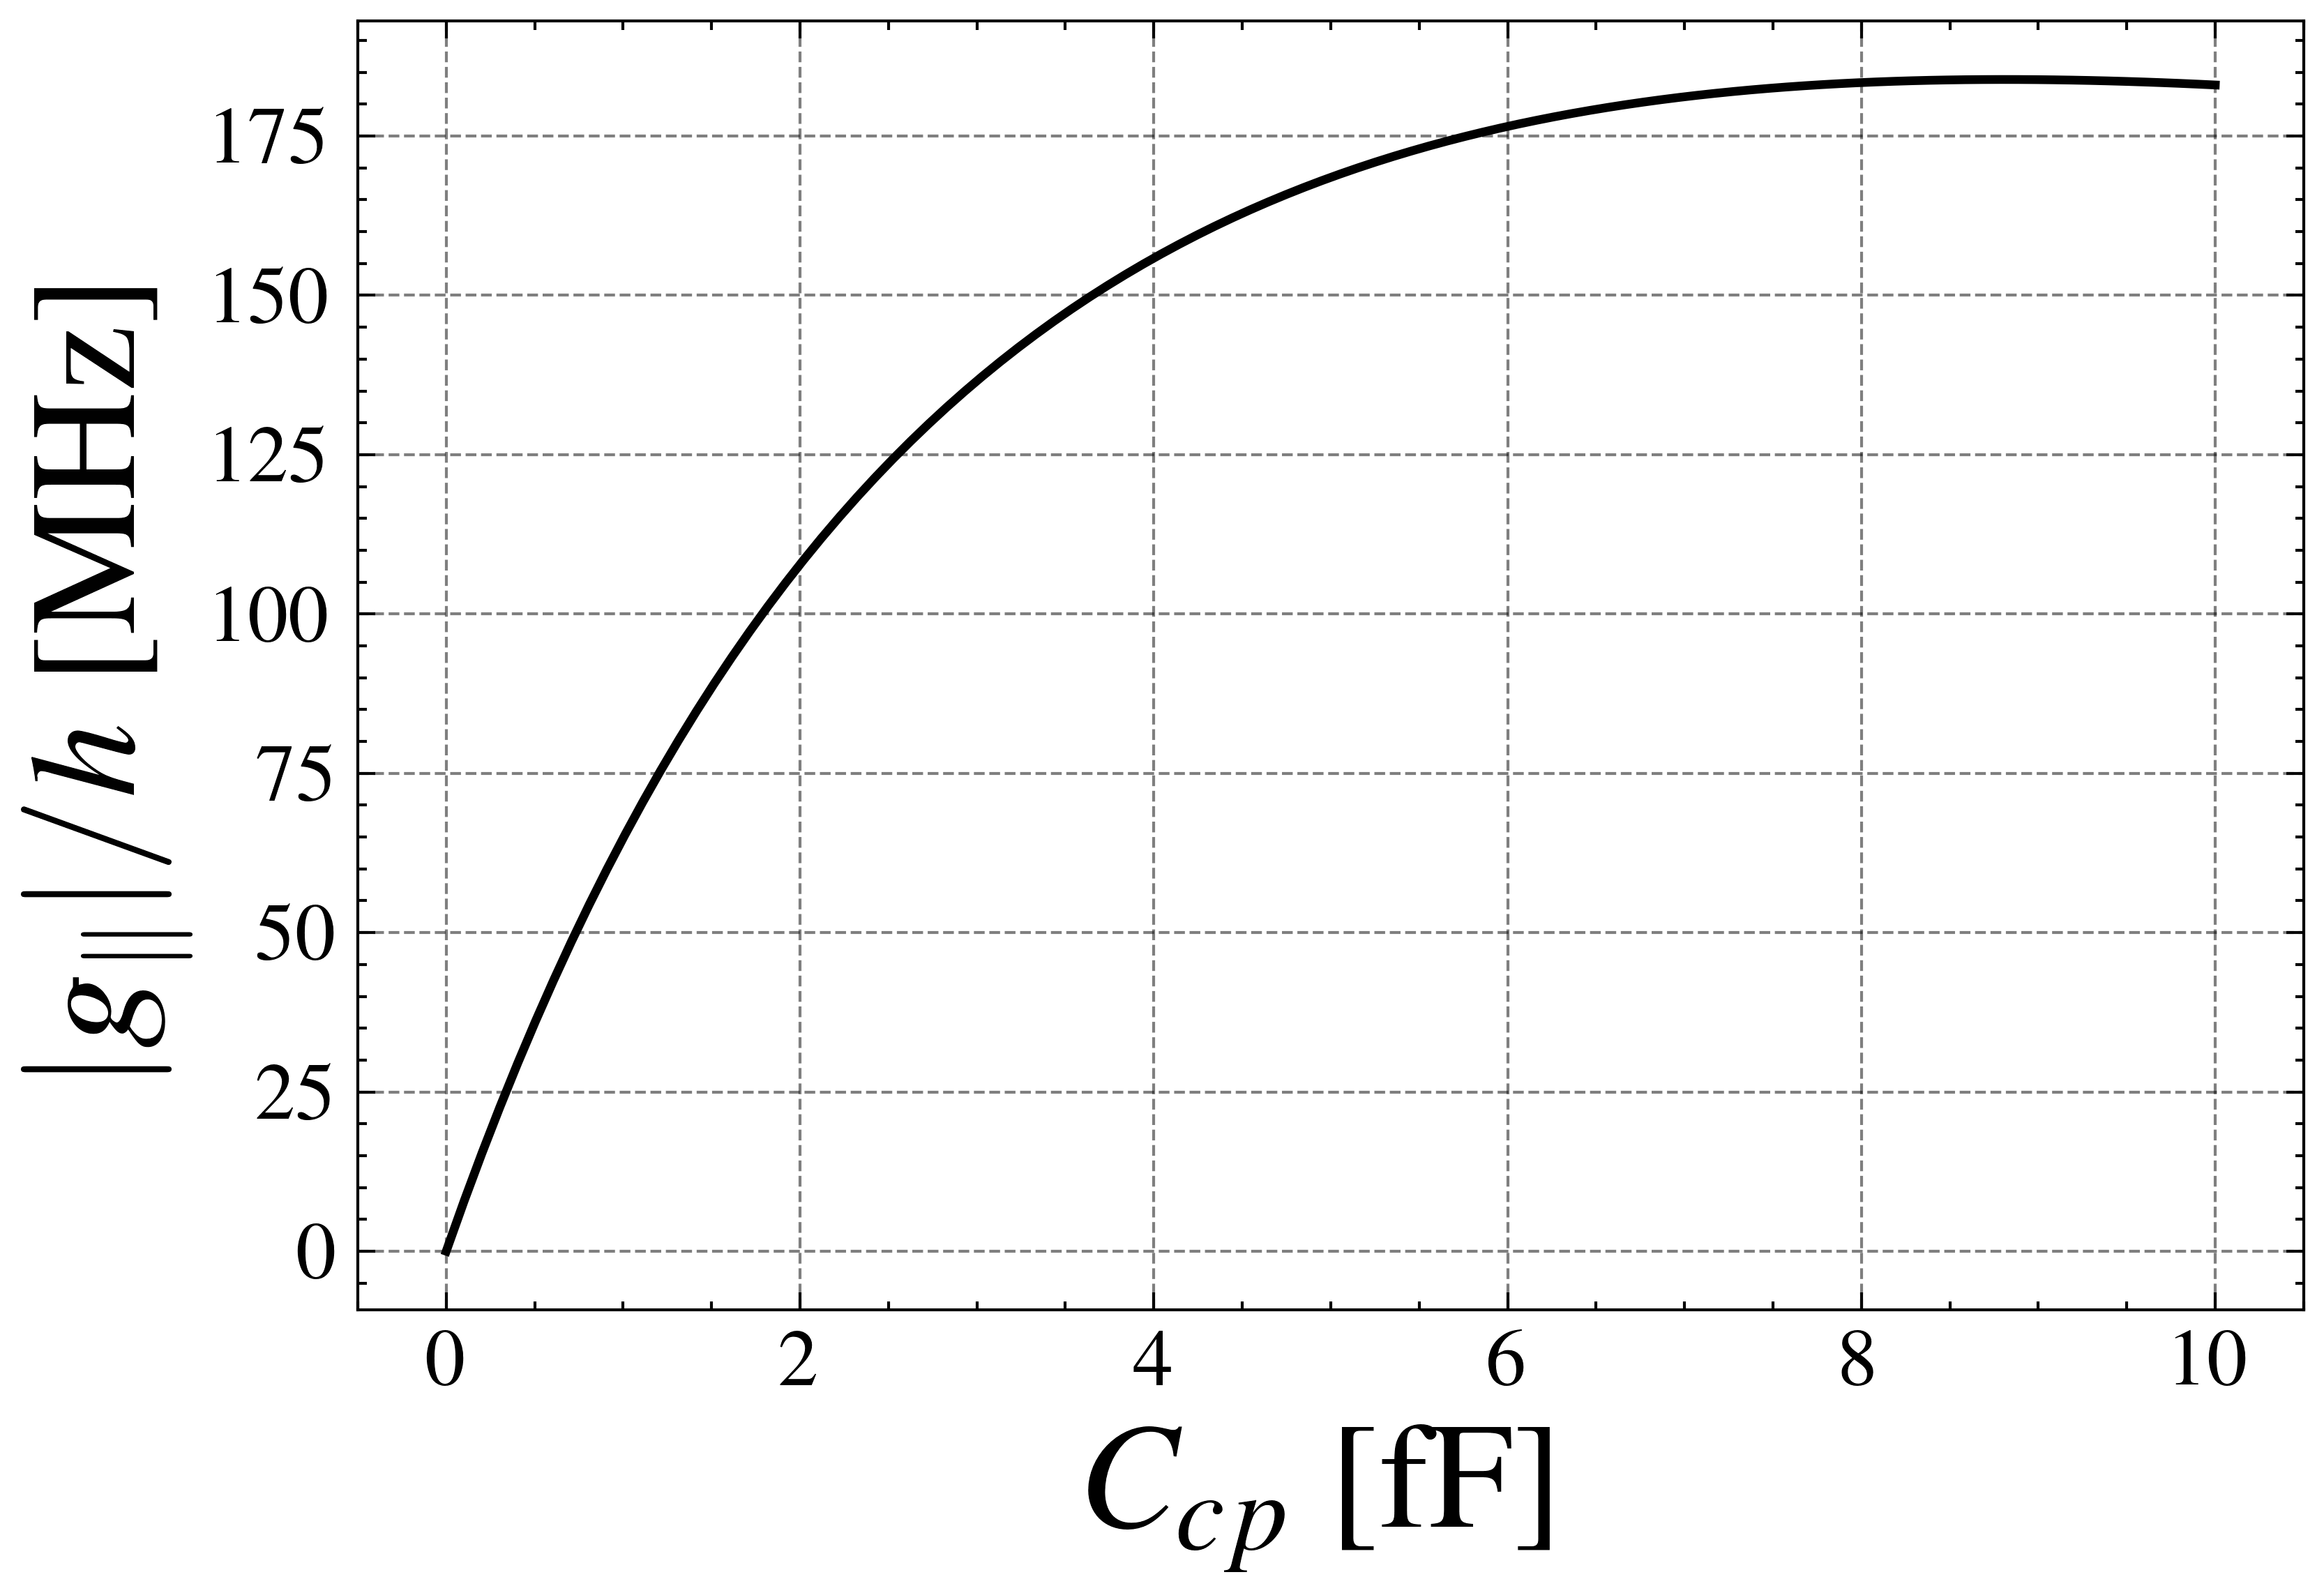

In [26]:
font = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 26}

fontlabel = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 17} 

fontticksaxis = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 14} 

# Create FontProperties objects
font_properties = FontProperties(**font)
fontlabel_properties = FontProperties(**fontlabel)
fontticksaxis_properties = FontProperties(**fontticksaxis) 

pparam = dict(xlabel='$C_{cp}$ [fF]', ylabel='$|g_\\parallel| / h$ [MHz]')

with plt.style.context(['ieee', 'grid']):
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot([val * 1e15 for val in fig_17d_Ccps_p], np.abs(fig_17d_results_p), linewidth=1.5)
    ax.set(**pparam)
    ax.xaxis.label.set_fontproperties(font_properties)
    ax.yaxis.label.set_fontproperties(font_properties)

    # Update the tick labels font
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(fontticksaxis_properties)
  
    #fig.savefig('/Users/e.lupo/Documents/00 Elenas files/charge tomography/Dan python codes last/figures/Resonator Coupling/g_parr_wrt_Ccp.png', dpi=400)
    plt.show()


#### couplings vs $n_g$, varying $\alpha_2 = \alpha_1 + \delta\alpha$

In [27]:
import pickle

fig_17c_ngs_p = np.linspace(-1, 1, 1000)
alpha2s = [0.4,0.4001,0.401,0.41]

system = RCCircuitCoup(ncut=5)

alpha_disp_results = {}

for alpha2 in alpha2s:
    if alpha2 in alpha_disp_results.keys():
        continue

    alpha_disp_results[alpha2] = {
        'ng': [],
        'g_parr': [],
        'g_perp': [],
        'probe_freq': [],
        #'cavity_freq': [],
        #'target_freq': []
    }

    system.alphas = [0.4, alpha2, 1, 1] 
    for ng in tqdm(fig_17c_ngs_p):
        system.ng = ng

        g_parr = system.calc_g_parr(update=True) * 1e-6 / h
        g_perp = system.calc_g_perp(update=True) * 1e-6 / h
        probe_freq = system.calc_probe_freq(update=True) * 1e-9 / h

        alpha_disp_results[alpha2]['ng'].append(ng)
        alpha_disp_results[alpha2]['g_parr'].append(g_parr)
        alpha_disp_results[alpha2]['g_perp'].append(g_perp)
        alpha_disp_results[alpha2]['probe_freq'].append(probe_freq)
    
    #with open('/Users/e.lupo/Documents/00 Elenas files/charge tomography/Dan python codes last/figures/Resonator Coupling/alpha_disp_results_zoom.pkl', 'wb') as f:
    #    pickle.dump(alpha_disp_results, f)


100%|██████████| 1000/1000 [03:45<00:00,  4.42it/s] 


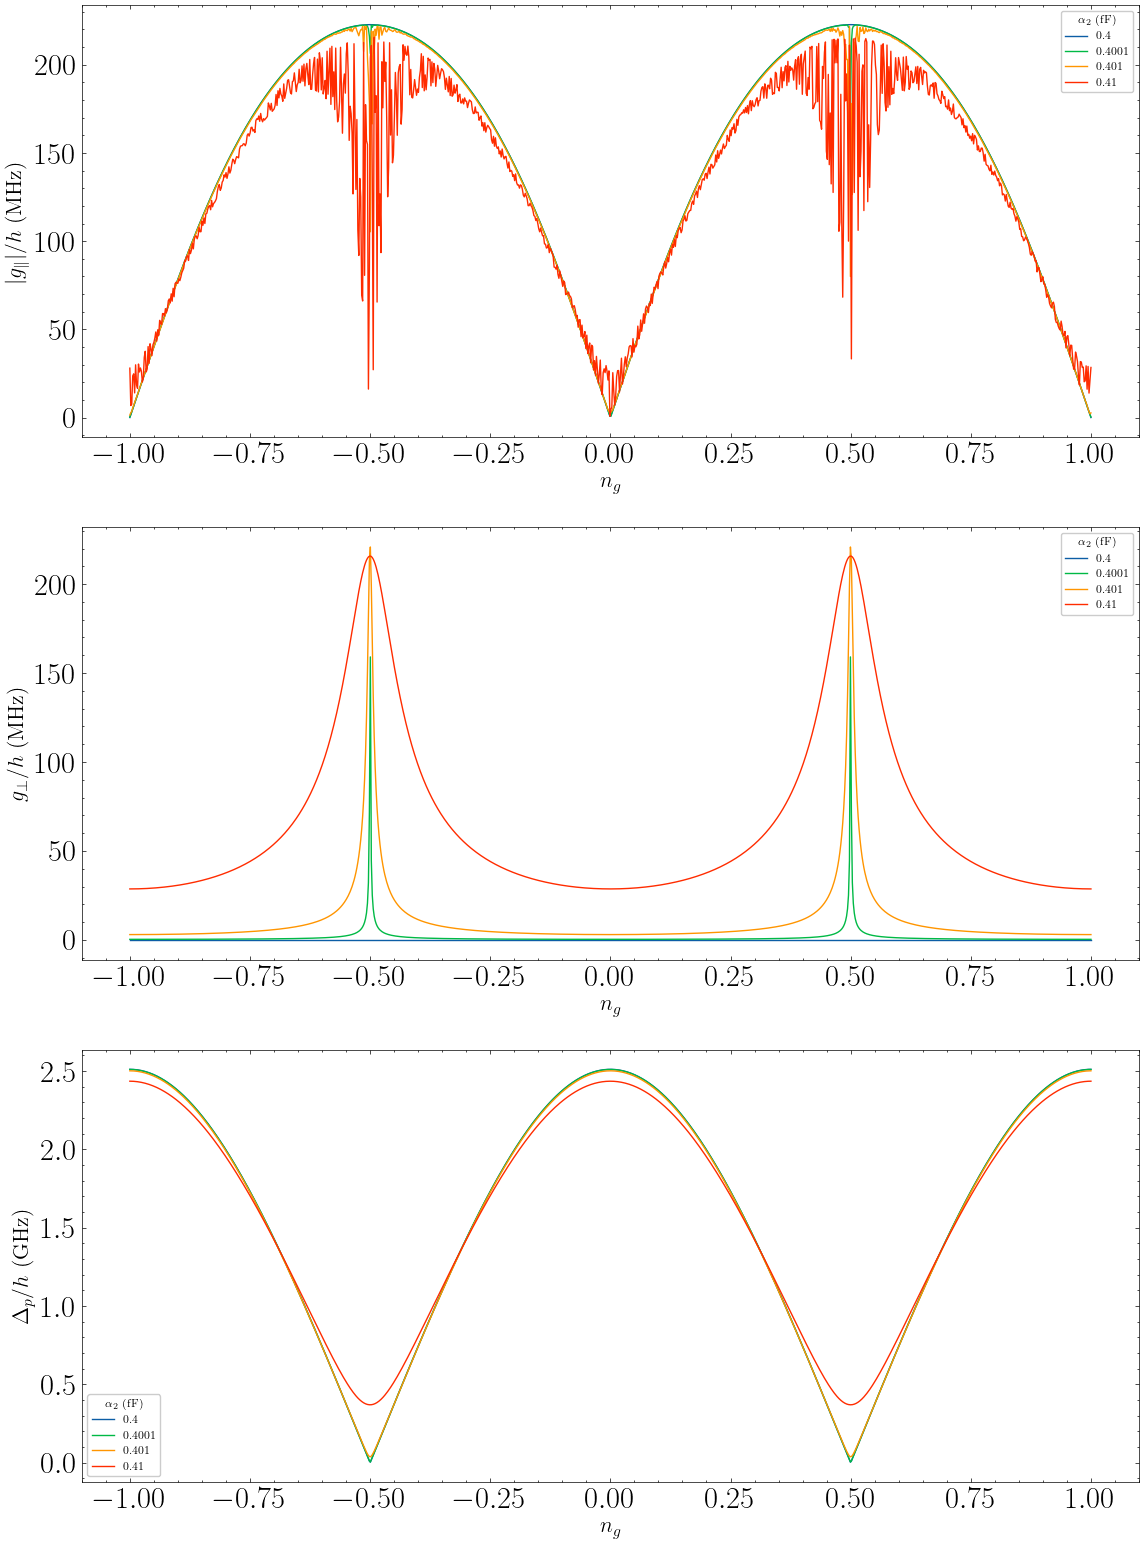

In [28]:
#with open('/Users/e.lupo/Documents/00 Elenas files/charge tomography/Dan python codes last/figures/Resonator Coupling/alpha_disp_results_zoom.pkl', 'rb') as f:
#    alpha_disp_results = pickle.load(f)



obserables = [
    {'name': 'g_parr', 'ylabel': '$|g_\\parallel| / h$ (MHz)'},
    {'name': 'g_perp', 'ylabel': '$g_\\perp / h$ (MHz)'},
    #{'name': 'cavity_freq', 'ylabel': '$omega / h$ (GHz)', 'y_lim': [0, 8]},
    {'name': 'probe_freq', 'ylabel': '$\\Delta_p / h$ (GHz)'},
    #{'name': 'target_freq', 'ylabel': '$\\Delta_t / h$ (GHz)', 'y_lim': [0, 8]}
]

fig, ax = plt.subplots(figsize=(12, 16), nrows=3, ncols=1)
ax = ax.flatten()
for idx, obs in enumerate(obserables):
    pparam = dict(xlabel='$n_g$', ylabel=obs['ylabel'])

    with plt.style.context(['ieee', 'grid']):
        for alpha in alpha_disp_results.keys():
            ax[idx].plot(alpha_disp_results[alpha]['ng'], np.abs(alpha_disp_results[alpha][obs['name']]), label=alpha)
        
        if 'y_lim' in obs.keys():
            ax[idx].set_ylim(obs['y_lim'])
        
        ax[idx].legend(title='$\\alpha_2$ (fF)')
        ax[idx].set(**pparam)
        ax[idx].xaxis.label.set_size(16)
        ax[idx].yaxis.label.set_size(16)

plt.tight_layout()
#fig.savefig(f'../figures/Resonator Coupling/alpha_disp_results.png', dpi=300)
plt.show()

In [29]:
alpha_labels_list=['0.0','$10^{-4}$','$10^{-3}$','$10^{-2}$']

alpha_labels = {}

for jind in range(0,4):
    alpha_labels[alpha2s[jind]] = alpha_labels_list[jind] 

print(alpha_labels)

{0.4: '0.0', 0.4001: '$10^{-4}$', 0.401: '$10^{-3}$', 0.41: '$10^{-2}$'}


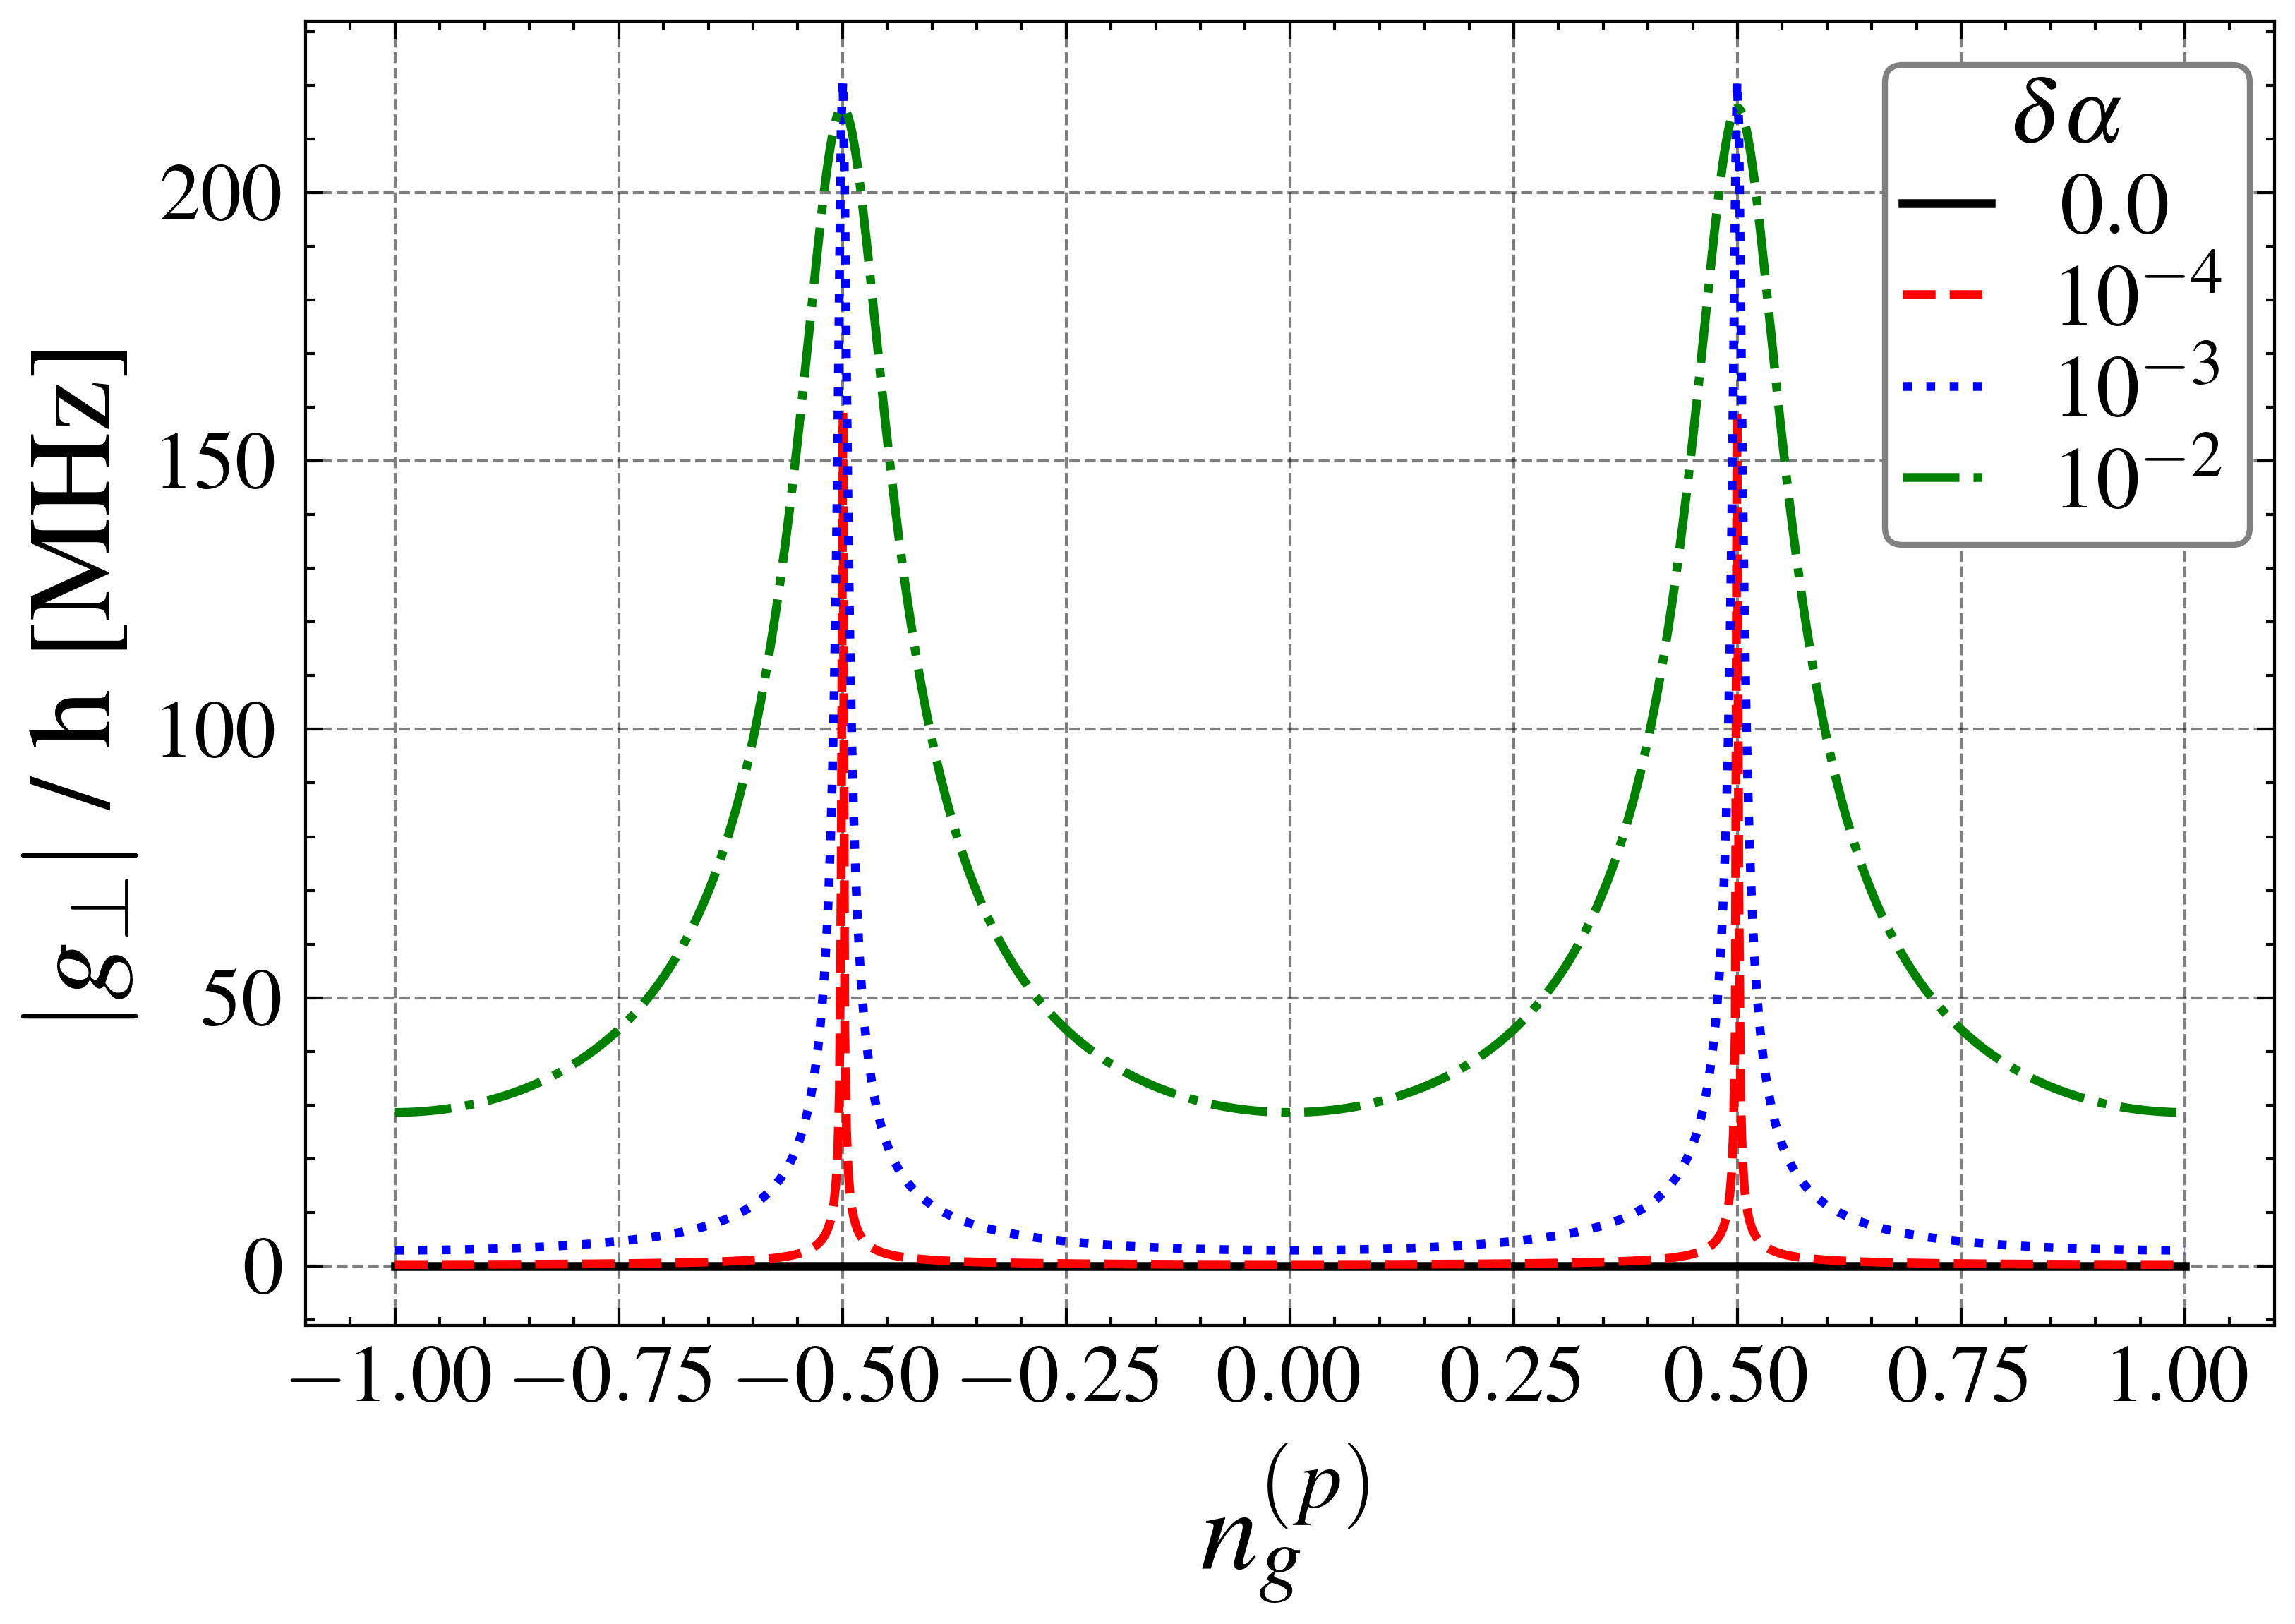

In [31]:
font = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 20}   #26

fontlabel = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 15} #17 

fontticksaxis = {'family' : 'roman',
        'weight' : 'bold',
        'size'   : 14} 

# Create FontProperties objects
font_properties = FontProperties(**font)
fontlabel_properties = FontProperties(**fontlabel)
fontticksaxis_properties = FontProperties(**fontticksaxis) 

obs = obserables[1] #g_perp

pparam = dict(xlabel='$n_g^{(p)}$', ylabel='$|g_\\perp|$ / h [MHz]')

with plt.style.context(['ieee', 'grid']):
    fig2, ax = plt.subplots(figsize=(6,4))
    
    for alpha2 in alpha_disp_results.keys():
        plt.plot(alpha_disp_results[alpha2]['ng'], np.abs(alpha_disp_results[alpha2][obs['name']]), label=alpha_labels[alpha2], linewidth=1.5)

    ax.legend(title='$\\delta\\alpha$', title_fontsize=fontlabel['size'], prop=fontlabel_properties,loc= 'upper right', bbox_to_anchor=(1.01, 1.0),labelspacing=0.12, handlelength=1, borderpad=0.2, frameon=True, 
    facecolor='white', 
    edgecolor='grey', 
    framealpha=1 )
    ax.set(**pparam)
    ax.xaxis.label.set_fontproperties(font_properties)
    ax.yaxis.label.set_fontproperties(font_properties)

    # Update the tick labels font
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(fontticksaxis_properties)
        
    #fig2.savefig('/Users/e.lupo/Documents/00 Elenas files/charge tomography/Dan python codes last/figures/Resonator Coupling/g_perp_wrt_ng_alpha2_bis.png', dpi=400)
    plt.show()

#### couplings vs $f_p$ (ext. flux), symmetric SQUID

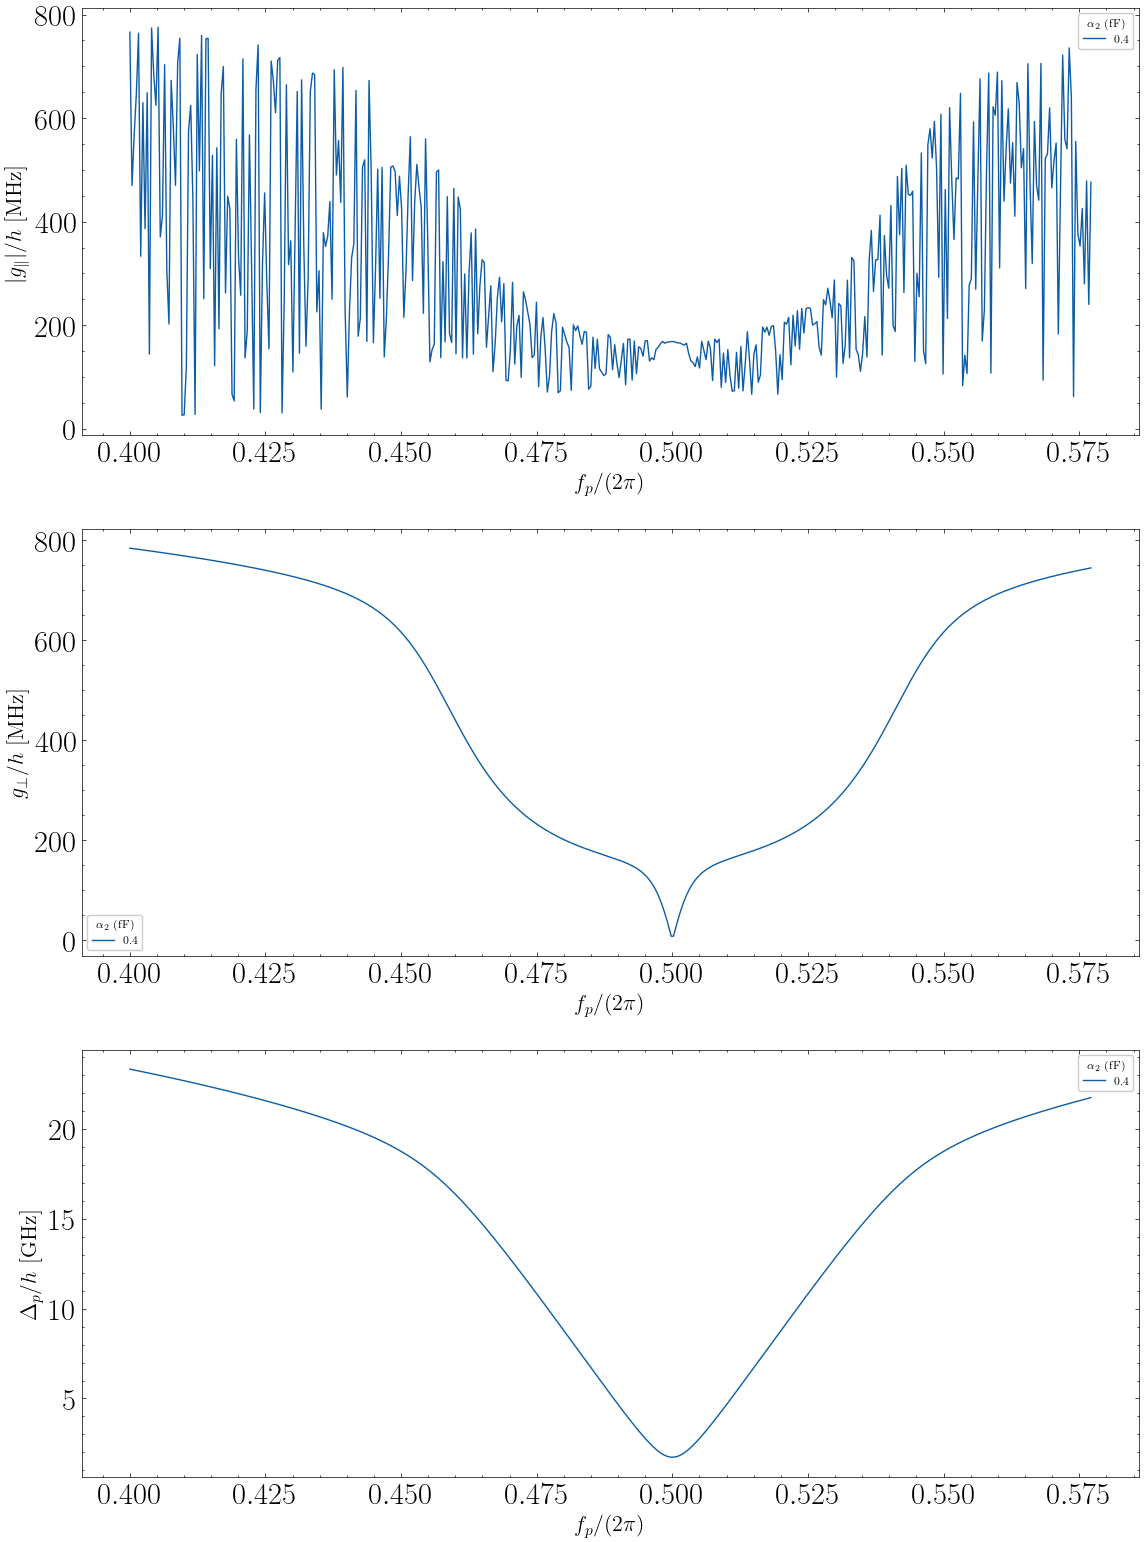

In [34]:
obserables = [
    {'name': 'g_parr', 'ylabel': '$|g_\\parallel| / h$ [MHz]'},
    {'name': 'g_perp', 'ylabel': '$g_\\perp / h$ [MHz]'},
    {'name': 'probe_freq', 'ylabel': '$\\Delta_p / h$ [GHz]'},
]


fig, ax = plt.subplots(figsize=(12, 16), nrows=3, ncols=1)
ax = ax.flatten()
for idx, obs in enumerate(obserables):
    pparam = dict(xlabel='$f_p/(2\\pi)$', ylabel=obs['ylabel'])

    with plt.style.context(['ieee', 'grid']):
        for alpha in alpha_disp_results_fp.keys():
            ax[idx].plot(alpha_disp_results_fp[alpha]['flux'], np.abs(alpha_disp_results_fp[alpha][obs['name']]), label=alpha)
        
        if 'y_lim' in obs.keys():
            ax[idx].set_ylim(obs['y_lim'])
        
        ax[idx].legend(title='$\\alpha_2$ (fF)')
        ax[idx].set(**pparam)
        ax[idx].xaxis.label.set_size(16)
        ax[idx].yaxis.label.set_size(16)

plt.tight_layout()
#fig.savefig(f'../figures/Resonator Coupling/alpha_disp_results_fp.png', dpi=300)
plt.show()